EDA & Consistency Analysis


this notebook covers:

1. Dataset overview and schema validation  
2. Missing values and field availability by event type  
3. Event/session distributions  
4. Timestamp, delay and token-expiry checks  
5. Authentication-flow consistency checks  
6. Token, nonce, label and state-transition checks  
7. Exportable row-level inconsistency report  


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

CSV_PATH = Path("iot_auth_dataset_event_log (8).csv")
if not CSV_PATH.exists():
    CSV_PATH = Path(r"C:\Users\lamia\Downloads\iot_auth_dataset_event_log (8).csv")

OUTPUT_DIR = Path("iot_auth_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH

WindowsPath('C:/Users/lamia/Downloads/iot_auth_dataset_event_log (8).csv')

In [3]:
df_raw = pd.read_csv(CSV_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())
display(df.dtypes.to_frame("dtype"))

Rows: 16,180
Columns: 26


,event_id,event_type,timestamp,delay_since_previous_event,scenario_id,session_id,device_id,gateway_id,auth_server_id,broker_id,previous_state,new_state,result,failure_reason,retry_count,token_id,token_expiry,token_scope,nonce,identity_claim,topic,resource_id,firmware_version,source_context,anomaly_label,attack_type
0,75337ecf-599c-4cf1-b752-a9786ca3ddc5,registration_request,2026-06-23 11:24:58,0.0000,9ed520f8-9c98-4994-b7bb-312528381a1d,31b0686f-58c4-4c61-aa19-eb1026cd7214,37a75edc-fc53-45f3-a5d7-ff7b109f897d,b836d6fd,auth-01,broker-01,unregistered,registered,success,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2.0,normal,NaN,normal
1,e7fb3ec1-b5c3-491d-9798-9c165fdfceba,registration_confirmed,2026-06-23 11:24:58,0.0631,9ed520f8-9c98-4994-b7bb-312528381a1d,31b0686f-58c4-4c61-aa19-eb1026cd7214,37a75edc-fc53-45f3-a5d7-ff7b109f897d,b836d6fd,auth-01,broker-01,registered,registered,success,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2.0,normal,NaN,normal
2,903c5d7f-2638-4b7f-b22b-751ed3720989,authentication_request,2026-06-23 11:24:58,0.1795,9ed520f8-9c98-4994-b7bb-312528381a1d,31b0686f-58c4-4c61-aa19-eb1026cd7214,37a75edc-fc53-45f3-a5d7-ff7b109f897d,b836d6fd,auth-01,broker-01,registered,auth_requested,success,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2.0,normal,NaN,normal
3,d145801c-e22a-438f-99ec-b00cb771df0d,challenge_sent,2026-06-23 11:24:58,0.0329,9ed520f8-9c98-4994-b7bb-312528381a1d,31b0686f-58c4-4c61-aa19-eb1026cd7214,37a75edc-fc53-45f3-a5d7-ff7b109f897d,b836d6fd,auth-01,broker-01,auth_requested,challenge_issued,success,NaN,0,NaN,NaN,NaN,1d74186c7fa21311,NaN,NaN,NaN,1.2.0,normal,NaN,normal
4,f8718d17-3b0f-4156-ac45-af86f489423d,nonce_received,2026-06-23 11:24:59,0.1312,9ed520f8-9c98-4994-b7bb-312528381a1d,31b0686f-58c4-4c61-aa19-eb1026cd7214,37a75edc-fc53-45f3-a5d7-ff7b109f897d,b836d6fd,auth-01,broker-01,challenge_issued,challenge_issued,success,NaN,0,NaN,NaN,NaN,1d74186c7fa21311,NaN,NaN,NaN,1.2.0,normal,NaN,normal


,dtype
event_id,str
event_type,str
timestamp,str
delay_since_previous_event,float64
scenario_id,str
session_id,str
device_id,str
gateway_id,str
auth_server_id,str
broker_id,str


## 1. Expected schema

The following schema corresponds to the event log structure used in the simulator: identifiers, event metadata, state transition fields, temporal fields, token/nonce/resource fields, and labels.

In [ ]:
expected_columns = [
    "event_id", "event_type", "timestamp", "delay_since_previous_event",
    "scenario_id", "session_id", "device_id", "gateway_id", "auth_server_id",
    "broker_id", "previous_state", "new_state", "result", "failure_reason",
    "retry_count", "token_id", "token_expiry", "token_scope", "nonce",
    "identity_claim", "topic", "resource_id", "firmware_version",
    "source_context", "anomaly_label", "attack_type",
]
    
schema_report = pd.DataFrame({
    "column": expected_columns,
    "present": [c in df.columns for c in expected_columns],
    "dtype": [str(df[c].dtype) if c in df.columns else None for c in expected_columns],
    "missing_count": [df[c].isna().sum() if c in df.columns else None for c in expected_columns],
    "missing_rate": [df[c].isna().mean() if c in df.columns else None for c in expected_columns],
    "unique_values": [df[c].nunique(dropna=True) if c in df.columns else None for c in expected_columns],
})

extra_columns = sorted(set(df.columns) - set(expected_columns))

display(schema_report)
print("Extra columns not in expected schema:", extra_columns)

,column,present,dtype,missing_count,missing_rate,unique_values
0,event_id,True,str,0,0.000000,16180
1,event_type,True,str,0,0.000000,17
2,timestamp,True,str,0,0.000000,224
3,delay_since_previous_event,True,float64,0,0.000000,5414
4,scenario_id,True,str,0,0.000000,1100
5,session_id,True,str,0,0.000000,1100
6,device_id,True,str,0,0.000000,199
7,gateway_id,True,str,0,0.000000,5
8,auth_server_id,True,str,0,0.000000,1
9,broker_id,True,str,0,0.000000,1


Extra columns not in expected schema: []


In [6]:
overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "sessions": df["session_id"].nunique(),
    "scenarios": df["scenario_id"].nunique(),
    "devices": df["device_id"].nunique(),
    "gateways": df["gateway_id"].nunique(),
    "auth_servers": df["auth_server_id"].nunique(),
    "brokers": df["broker_id"].nunique(),
    "event_types": df["event_type"].nunique(),
    "attack_rows_source_context": int(df["is_attack_row"].sum()),
    "attack_scenario_rows_attack_type": int(df["is_attack_scenario"].sum()),
    "failure_rows": int(df["is_failure"].sum()),
    "duplicate_event_ids": int(df["event_id"].duplicated().sum()),
    "invalid_timestamps": int(df["timestamp_dt"].isna().sum()),
    "invalid_token_expiry_values": int(df["token_expiry"].notna().sum() - df["token_expiry_dt"].notna().sum()),
}).to_frame("value")

display(overview)

display(Markdown("### Event type distribution"))
display(df["event_type"].value_counts().to_frame("rows"))

display(Markdown("### Result distribution"))
display(df["result"].value_counts(dropna=False).to_frame("rows"))

display(Markdown("### Attack type distribution"))
display(df["attack_type"].value_counts(dropna=False).to_frame("rows"))

display(Markdown("### Source context distribution"))
display(df["source_context"].value_counts(dropna=False).to_frame("rows"))

,value
rows,16180
columns,33
sessions,1100
scenarios,1100
devices,199
gateways,5
auth_servers,1
brokers,1
event_types,17
attack_rows_source_context,100


### Event type distribution

,rows
event_type,
nonce_received,1264
response_sent,1264
challenge_sent,1252
token_presented,1173
token_issued,1169
token_validated,1161
registration_request,1116
registration_confirmed,1100
authentication_request,1056


### Result distribution

,rows
result,
success,15595
failure,585


### Attack type distribution

,rows
attack_type,
normal,15600
duplicate_sequence,121
nonce_reuse,96
impersonation,84
abnormal_renewal,72
abnormal_failure_rate,63
identity_token_mismatch,36
access_without_auth,36
timestamp_inconsistency,36


### Source context distribution

,rows
source_context,
normal,16080
attack,100


## 2. Type conversion and derived fields

Timestamps are parsed into datetime columns. A row number is added to preserve the generated event order, which is important because timestamps are rounded to seconds while delays are sub-second.

In [5]:
# Preserve generation order.
df["_row_number"] = np.arange(len(df))

# Parse temporal fields.
df["timestamp_dt"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["token_expiry_dt"] = pd.to_datetime(df["token_expiry"], errors="coerce")

# Useful derived fields.
df["is_failure"] = df["result"].eq("failure")
df["is_attack_row"] = df["source_context"].eq("attack")
df["is_attack_scenario"] = df["attack_type"].ne("normal")
df["state_transition"] = df["previous_state"].astype(str) + " -> " + df["new_state"].astype(str)

# Sort by the original generated order inside each session.
df_ordered = df.sort_values(["session_id", "_row_number"]).copy()
df_ordered["timestamp_delta_seconds"] = (
    df_ordered.groupby("session_id")["timestamp_dt"].diff().dt.total_seconds()
)

display(df[[
    "_row_number", "event_id", "event_type", "timestamp", "timestamp_dt",
    "delay_since_previous_event", "session_id", "previous_state", "new_state",
    "result", "source_context", "attack_type", "anomaly_label"
]].head())

,_row_number,event_id,event_type,timestamp,timestamp_dt,delay_since_previous_event,session_id,previous_state,new_state,result,source_context,attack_type,anomaly_label
0,0,75337ecf-599c-4cf1-b752-a9786ca3ddc5,registration_request,2026-06-23 11:24:58,2026-06-23 11:24:58,0.0000,31b0686f-58c4-4c61-aa19-eb1026cd7214,unregistered,registered,success,normal,normal,NaN
1,1,e7fb3ec1-b5c3-491d-9798-9c165fdfceba,registration_confirmed,2026-06-23 11:24:58,2026-06-23 11:24:58,0.0631,31b0686f-58c4-4c61-aa19-eb1026cd7214,registered,registered,success,normal,normal,NaN
2,2,903c5d7f-2638-4b7f-b22b-751ed3720989,authentication_request,2026-06-23 11:24:58,2026-06-23 11:24:58,0.1795,31b0686f-58c4-4c61-aa19-eb1026cd7214,registered,auth_requested,success,normal,normal,NaN
3,3,d145801c-e22a-438f-99ec-b00cb771df0d,challenge_sent,2026-06-23 11:24:58,2026-06-23 11:24:58,0.0329,31b0686f-58c4-4c61-aa19-eb1026cd7214,auth_requested,challenge_issued,success,normal,normal,NaN
4,4,f8718d17-3b0f-4156-ac45-af86f489423d,nonce_received,2026-06-23 11:24:59,2026-06-23 11:24:59,0.1312,31b0686f-58c4-4c61-aa19-eb1026cd7214,challenge_issued,challenge_issued,success,normal,normal,NaN


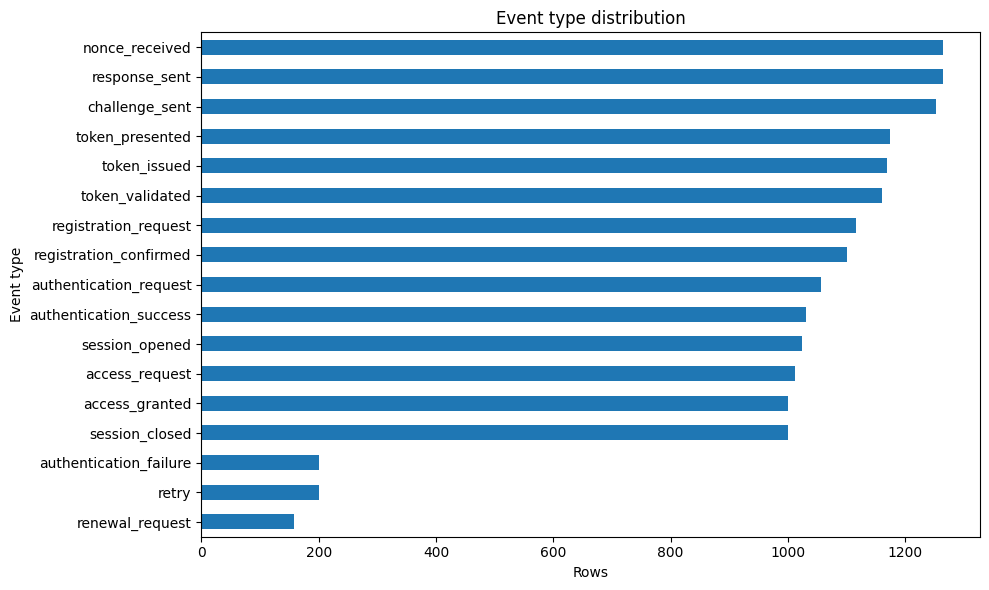

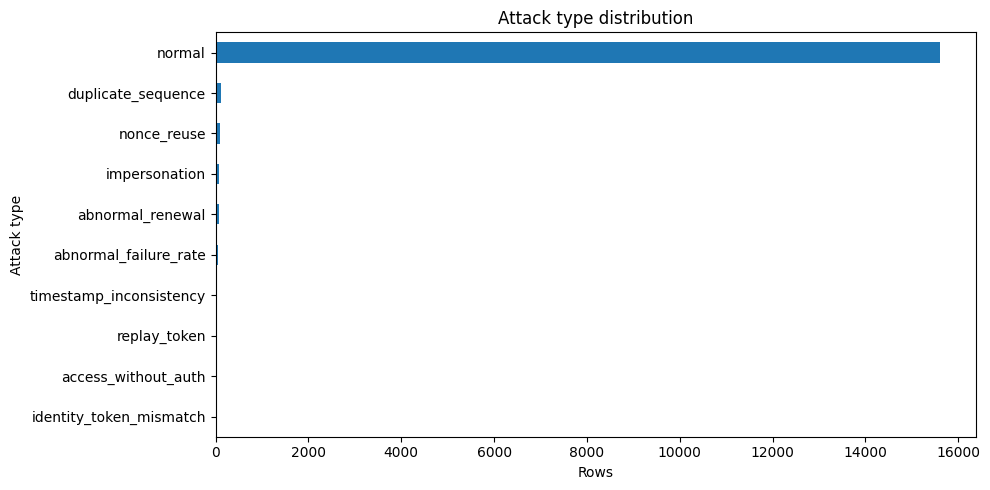

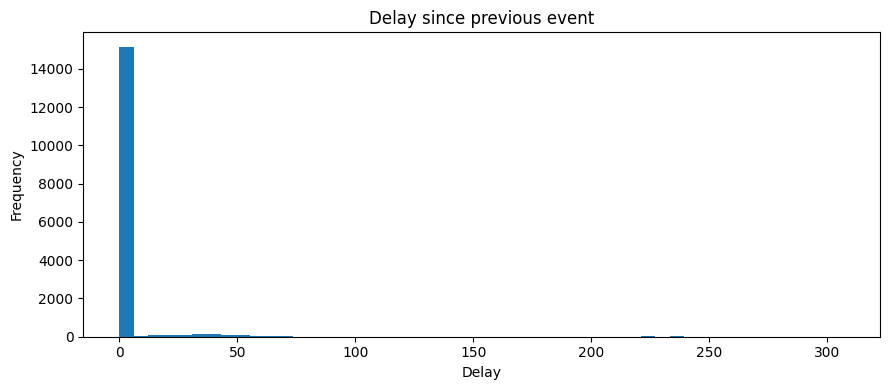

In [7]:
# Basic plots. Matplotlib only.
ax = df["event_type"].value_counts().sort_values().plot(kind="barh", figsize=(10, 6))
ax.set_title("Event type distribution")
ax.set_xlabel("Rows")
ax.set_ylabel("Event type")
plt.tight_layout()
plt.show()

ax = df["attack_type"].value_counts().sort_values().plot(kind="barh", figsize=(10, 5))
ax.set_title("Attack type distribution")
ax.set_xlabel("Rows")
ax.set_ylabel("Attack type")
plt.tight_layout()
plt.show()

ax = df["delay_since_previous_event"].plot(kind="hist", bins=50, figsize=(9, 4))
ax.set_title("Delay since previous event")
ax.set_xlabel("Delay")
plt.tight_layout()
plt.show()

## 4. Missingness analysis

Some missing values are expected. For example, token fields should be absent before token issuance, and nonce should only appear around challenge/response events. The important part is to check whether missingness matches event semantics.

In [8]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "present_count": df.notna().sum(),
        "unique_values": df.nunique(dropna=True),
        "dtype": df.dtypes.astype(str),
    })
    .sort_values("missing_rate", ascending=False)
)

display(missing_summary)
missing_summary.to_csv(OUTPUT_DIR / "missingness_summary.csv")

# Missingness by event type for important optional fields.
optional_fields = [
    "failure_reason", "token_id", "token_expiry", "token_scope",
    "nonce", "identity_claim", "topic", "resource_id", "anomaly_label"
]

missing_by_event_type = (
    df.groupby("event_type")[optional_fields]
      .apply(lambda x: x.isna().mean())
      .round(3)
)

display(missing_by_event_type)
missing_by_event_type.to_csv(OUTPUT_DIR / "missingness_by_event_type.csv")

,missing_count,missing_rate,present_count,unique_values,dtype
identity_claim,16156,0.998517,24,24,str
anomaly_label,16080,0.993820,100,9,str
failure_reason,15595,0.963844,585,11,str
resource_id,14168,0.875649,2012,199,str
topic,13144,0.812361,3036,199,str
nonce,12412,0.767120,3768,1252,str
token_expiry_dt,9531,0.589061,6649,91,datetime64[us]
token_expiry,9531,0.589061,6649,91,str
token_id,9519,0.588319,6661,1181,str
token_scope,9519,0.588319,6661,4,str


,failure_reason,token_id,token_expiry,token_scope,nonce,identity_claim,topic,resource_id,anomaly_label
event_type,,,,,,,,,
access_granted,0.977,0.000,0.000,0.000,1.000,1.000,0.0,0.0,1.000
access_request,0.967,0.012,0.012,0.012,1.000,1.000,0.0,0.0,0.988
authentication_failure,0.000,1.000,1.000,1.000,1.000,1.000,1.0,1.0,1.000
authentication_request,0.983,1.000,1.000,1.000,1.000,1.000,1.0,1.0,0.996
authentication_success,0.978,1.000,1.000,1.000,1.000,1.000,1.0,1.0,1.000
challenge_sent,0.981,1.000,1.000,1.000,0.000,1.000,1.0,1.0,1.000
nonce_received,0.976,1.000,1.000,1.000,0.000,1.000,1.0,1.0,0.991
registration_confirmed,1.000,1.000,1.000,1.000,1.000,1.000,1.0,1.0,1.000
registration_request,0.986,1.000,1.000,1.000,1.000,1.000,1.0,1.0,0.986


In [ ]:
# Visualize missingness rates by column.
ax = missing_summary["missing_rate"].sort_values().plot(kind="barh", figsize=(9, 6))
ax.set_title("Missing rate by column")
ax.set_xlabel("Missing rate")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

## 5. Session-level structure

This section checks whether each session has stable IDs and a plausible number of events.

In [ ]:
session_summary = (
    df.groupby("session_id")
      .agg(
          rows=("event_id", "count"),
          scenario_count=("scenario_id", "nunique"),
          device_count=("device_id", "nunique"),
          gateway_count=("gateway_id", "nunique"),
          auth_server_count=("auth_server_id", "nunique"),
          broker_count=("broker_id", "nunique"),
          firmware_count=("firmware_version", "nunique"),
          failure_rows=("is_failure", "sum"),
          attack_rows=("is_attack_row", "sum"),
          attack_scenario_rows=("is_attack_scenario", "sum"),
          first_timestamp=("timestamp_dt", "min"),
          last_timestamp=("timestamp_dt", "max"),
      )
      .reset_index()
)

session_summary["duration_seconds"] = (
    session_summary["last_timestamp"] - session_summary["first_timestamp"]
).dt.total_seconds()

# Attack types per session.
attack_types_per_session = (
    df.groupby("session_id")["attack_type"]
      .agg(lambda s: ", ".join(sorted(set(s.dropna().astype(str)))))
      .rename("attack_types")
      .reset_index()
)

session_summary = session_summary.merge(attack_types_per_session, on="session_id", how="left")

display(session_summary.head())
display(session_summary["rows"].describe().to_frame("session_event_count"))

session_summary.to_csv(OUTPUT_DIR / "session_summary.csv", index=False)

ax = session_summary["rows"].plot(kind="hist", bins=30, figsize=(9, 4))
ax.set_title("Events per session")
ax.set_xlabel("Number of events")
plt.tight_layout()
plt.show()

## 6. Normal authentication-flow baseline

The notebook derives the normal baseline directly from sessions whose `attack_type == 'normal'`.

This avoids hard-coding a single path, because the simulator may include valid variants such as authentication retry or token renewal.

In [ ]:
# Sessions that contain only normal labels.
session_attack_sets = (
    df.groupby("session_id")["attack_type"]
      .agg(lambda s: tuple(sorted(set(s.dropna().astype(str)))))
)

normal_session_ids = session_attack_sets[session_attack_sets.apply(lambda x: x == ("normal",))].index

normal_sequences = (
    df[df["session_id"].isin(normal_session_ids)]
      .sort_values("_row_number")
      .groupby("session_id")["event_type"]
      .agg(tuple)
)

normal_sequence_patterns = normal_sequences.value_counts().reset_index()
normal_sequence_patterns.columns = ["event_sequence", "session_count"]

display(Markdown("### Normal sequence patterns inferred from the dataset"))
display(normal_sequence_patterns)

# All session sequences.
all_sequences = (
    df.sort_values("_row_number")
      .groupby("session_id")["event_type"]
      .agg(tuple)
)

valid_normal_sequence_set = set(normal_sequence_patterns["event_sequence"])
sessions_with_unexpected_sequence = all_sequences[~all_sequences.isin(valid_normal_sequence_set)]

print(f"Normal baseline sessions: {len(normal_session_ids):,}")
print(f"Normal baseline sequence patterns: {len(valid_normal_sequence_set):,}")
print(f"Sessions not matching normal baseline sequence patterns: {len(sessions_with_unexpected_sequence):,}")

unexpected_sequence_summary = (
    pd.DataFrame({
        "session_id": sessions_with_unexpected_sequence.index,
        "event_sequence": sessions_with_unexpected_sequence.values,
    })
    .merge(session_summary[["session_id", "attack_types", "rows", "failure_rows", "attack_rows"]], on="session_id", how="left")
)

display(unexpected_sequence_summary.head(20))
unexpected_sequence_summary.to_csv(OUTPUT_DIR / "sessions_with_unexpected_sequence.csv", index=False)

## 7. State-transition baseline

For each event type, the notebook learns allowed state transitions from pure normal scenarios, then flags any row whose `(previous_state -> new_state)` is not seen in that normal baseline.

In [ ]:
normal_rows = df[df["attack_type"].eq("normal")].copy()

allowed_transitions = (
    normal_rows.groupby("event_type")["state_transition"]
               .agg(lambda s: sorted(set(s)))
               .to_dict()
)

allowed_transition_table = (
    pd.DataFrame([
        {"event_type": event_type, "allowed_state_transition": transition}
        for event_type, transitions in allowed_transitions.items()
        for transition in transitions
    ])
    .sort_values(["event_type", "allowed_state_transition"])
)

display(allowed_transition_table)
allowed_transition_table.to_csv(OUTPUT_DIR / "allowed_state_transitions_from_normal_baseline.csv", index=False)

df["unexpected_state_transition_vs_normal"] = [
    row["state_transition"] not in allowed_transitions.get(row["event_type"], [])
    for _, row in df.iterrows()
]

unexpected_transition_rows = df[df["unexpected_state_transition_vs_normal"]].copy()

print(f"Rows with unexpected state transition vs normal baseline: {len(unexpected_transition_rows):,}")
display(unexpected_transition_rows[[
    "_row_number", "event_id", "session_id", "event_type", "state_transition",
    "result", "failure_reason", "source_context", "attack_type", "anomaly_label"
]].head(30))

## 8. Field-presence rules inferred from normal successful rows

Instead of manually assuming which fields are required, this section learns expected field presence by event type from normal successful rows.

Rule:

- If a field is present in more than 95% of normal successful rows for an event type, it is treated as required.
- If a field is present in less than 5% of normal successful rows for an event type, it is treated as usually absent.

In [ ]:
fields_to_profile = [
    "token_id", "token_expiry", "token_scope",
    "nonce", "identity_claim", "topic", "resource_id"
]

baseline_success = df[df["attack_type"].eq("normal") & df["result"].eq("success")].copy()

field_presence_rate = (
    baseline_success.groupby("event_type")[fields_to_profile]
                    .apply(lambda x: x.notna().mean())
                    .round(3)
)

required_field_matrix = field_presence_rate.gt(0.95)
usually_absent_field_matrix = field_presence_rate.lt(0.05)

display(Markdown("### Field presence rate in normal successful rows"))
display(field_presence_rate)

display(Markdown("### Required fields inferred from baseline"))
display(required_field_matrix)

field_presence_rate.to_csv(OUTPUT_DIR / "field_presence_rate_normal_success.csv")
required_field_matrix.to_csv(OUTPUT_DIR / "required_fields_inferred_from_normal_success.csv")

## 9. Inconsistency report

This section creates a row-level report. The report includes:

- **High severity**: strong logical inconsistencies or attack-transition violations  
- **Medium severity**: likely malformed or semantically suspicious rows  
- **Low severity**: quality issues that may or may not be intentional  
- **Info**: useful interpretation notes, not necessarily errors

In [ ]:
base_cols = [
    "_row_number", "event_id", "scenario_id", "session_id", "device_id",
    "event_type", "timestamp", "delay_since_previous_event",
    "previous_state", "new_state", "state_transition",
    "result", "failure_reason", "retry_count",
    "token_id", "token_expiry", "token_scope", "nonce",
    "identity_claim", "topic", "resource_id",
    "source_context", "anomaly_label", "attack_type"
]
base_cols = [c for c in base_cols if c in df.columns]

issue_frames = []

def add_issue(mask, issue_type, severity, explanation):
    # Append matching rows to the issue report.
    if isinstance(mask, pd.Series):
        mask = mask.reindex(df.index, fill_value=False)
    else:
        mask = pd.Series(mask, index=df.index)
    if int(mask.sum()) == 0:
        return
    tmp = df.loc[mask, base_cols].copy()
    tmp["issue_type"] = issue_type
    tmp["severity"] = severity
    tmp["explanation"] = explanation
    issue_frames.append(tmp)

# 1. Basic schema and identifier checks.
mandatory_cols = [
    "event_id", "event_type", "timestamp", "scenario_id", "session_id", "device_id",
    "gateway_id", "auth_server_id", "broker_id", "previous_state", "new_state",
    "result", "retry_count", "source_context", "attack_type"
]
for col in mandatory_cols:
    if col in df.columns:
        add_issue(df[col].isna(), f"missing_mandatory_column_value:{col}", "high",
                  f"Mandatory column `{col}` is missing.")

add_issue(df["event_id"].duplicated(keep=False), "duplicate_event_id", "high",
          "event_id should uniquely identify each event row.")

# 2. Temporal checks.
add_issue(df["timestamp_dt"].isna(), "invalid_timestamp", "high",
          "timestamp could not be parsed as datetime.")

add_issue(df["token_expiry"].notna() & df["token_expiry_dt"].isna(), "invalid_token_expiry", "medium",
          "token_expiry is present but could not be parsed as datetime.")

add_issue(df["delay_since_previous_event"].lt(0), "negative_delay_since_previous_event", "high",
          "Delay since previous event should not be negative.")

# First event per session should usually have delay 0.
first_row_idx = df.sort_values("_row_number").groupby("session_id").head(1).index
first_delay_mask = pd.Series(False, index=df.index)
first_delay_mask.loc[first_row_idx] = df.loc[first_row_idx, "delay_since_previous_event"].fillna(-1).ne(0)
add_issue(first_delay_mask, "first_event_delay_not_zero", "medium",
          "The first event of a session should normally have delay_since_previous_event = 0.")

# Timestamp should not go backwards inside the generated order of a session.
timestamp_backwards_idx = df_ordered[df_ordered["timestamp_delta_seconds"].lt(0)].index
timestamp_backwards_mask = pd.Series(False, index=df.index)
timestamp_backwards_mask.loc[timestamp_backwards_idx] = True
add_issue(timestamp_backwards_mask, "timestamp_goes_backwards_within_session", "high",
          "Timestamp decreases compared with the previous generated event in the same session.")

# Token expiry should be after the event timestamp where present.
add_issue(
    df["token_expiry_dt"].notna() & df["timestamp_dt"].notna() & df["token_expiry_dt"].le(df["timestamp_dt"]),
    "token_expiry_not_after_timestamp",
    "high",
    "token_expiry should be after the event timestamp."
)

# 3. Result/failure consistency.
add_issue(df["result"].eq("failure") & df["failure_reason"].isna(), "failure_without_failure_reason", "high",
          "Rows marked as failure should have a failure_reason.")

add_issue(df["result"].eq("success") & df["failure_reason"].notna(), "success_with_failure_reason", "high",
          "Rows marked as success should not have a failure_reason.")

# 4. Label consistency.
add_issue(df["source_context"].eq("attack") & df["anomaly_label"].isna(), "attack_row_without_anomaly_label", "high",
          "Rows with source_context='attack' should have an anomaly_label.")

add_issue(df["source_context"].eq("normal") & df["anomaly_label"].notna(), "normal_row_with_anomaly_label", "high",
          "Rows with source_context='normal' should not have an anomaly_label.")

add_issue(df["source_context"].eq("attack") & df["attack_type"].eq("normal"), "attack_row_with_normal_attack_type", "high",
          "Attack rows should not have attack_type='normal'.")

add_issue(
    df["source_context"].eq("attack") & df["anomaly_label"].notna() & df["attack_type"].ne(df["anomaly_label"]),
    "attack_type_anomaly_label_mismatch",
    "high",
    "For attack rows, attack_type should match anomaly_label."
)

# This is informational: attack_type appears to label the whole scenario, not only the attack row.
add_issue(
    df["source_context"].eq("normal") & df["attack_type"].ne("normal"),
    "scenario_attack_type_on_normal_context_row",
    "info",
    "This row is normal in source_context but belongs to an attack scenario. This is not necessarily wrong, but it matters for ML labeling."
)

# 5. State transition consistency.
add_issue(
    df["unexpected_state_transition_vs_normal"],
    "unexpected_state_transition_vs_normal_baseline",
    "high",
    "The event's previous_state -> new_state pair is not observed for this event_type in normal baseline sessions."
)

# 6. Field presence inferred from normal successful baseline.
for event_type in required_field_matrix.index:
    for col in required_field_matrix.columns:
        if bool(required_field_matrix.loc[event_type, col]):
            add_issue(
                df["event_type"].eq(event_type) & df[col].isna(),
                f"required_field_missing:{event_type}:{col}",
                "medium",
                f"`{col}` is normally required for event_type `{event_type}` based on normal successful rows."
            )
        if bool(usually_absent_field_matrix.loc[event_type, col]):
            add_issue(
                df["event_type"].eq(event_type) & df[col].notna(),
                f"usually_absent_field_present:{event_type}:{col}",
                "low",
                f"`{col}` is usually absent for event_type `{event_type}` based on normal successful rows."
            )

# 7. Entity stability inside one session.
stable_session_fields = ["scenario_id", "device_id", "gateway_id", "auth_server_id", "broker_id", "firmware_version"]
for col in stable_session_fields:
    varying_sessions = df.groupby("session_id")[col].nunique(dropna=False)
    bad_sessions = varying_sessions[varying_sessions.gt(1)].index
    add_issue(
        df["session_id"].isin(bad_sessions),
        f"session_has_multiple_values_for:{col}",
        "high",
        f"`{col}` should usually stay constant within a session."
    )

# 8. Topic/resource consistency with device ID prefix.
device_prefix = df["device_id"].astype(str).str.split("-").str[0]
topic_mismatch = pd.Series(
    [pd.notna(topic) and (prefix not in str(topic)) for prefix, topic in zip(device_prefix, df["topic"])],
    index=df.index
)
resource_mismatch = pd.Series(
    [pd.notna(resource) and (prefix not in str(resource)) for prefix, resource in zip(device_prefix, df["resource_id"])],
    index=df.index
)
add_issue(topic_mismatch, "topic_device_id_mismatch", "high",
          "MQTT topic does not contain the expected device ID prefix.")

add_issue(resource_mismatch, "resource_id_device_id_mismatch", "high",
          "resource_id does not contain the expected device ID prefix.")

# 9. Token causality: a token should be issued earlier in the same session before being presented/validated/used.
token_use_events = ["token_presented", "token_validated", "session_opened", "access_request", "access_granted", "renewal_request"]
token_without_prior_issue_idx = []
for session_id, g in df.sort_values("_row_number").groupby("session_id"):
    issued_tokens = set()
    for idx, row in g.iterrows():
        if row["event_type"] == "token_issued" and pd.notna(row["token_id"]):
            issued_tokens.add(row["token_id"])
        if row["event_type"] in token_use_events and pd.notna(row["token_id"]):
            if row["token_id"] not in issued_tokens:
                token_without_prior_issue_idx.append(idx)

token_without_prior_issue_mask = pd.Series(False, index=df.index)
token_without_prior_issue_mask.loc[token_without_prior_issue_idx] = True
add_issue(
    token_without_prior_issue_mask,
    "token_used_without_prior_token_issued_in_same_session",
    "high",
    "A token appears in a token-use event before a matching token_issued event in the same session."
)

# 10. Nonce reuse within same session and same event type.
nonce_rows = df[df["nonce"].notna()].copy()
duplicate_nonce_event_idx = nonce_rows[
    nonce_rows.duplicated(["session_id", "event_type", "nonce"], keep=False)
].index

duplicate_nonce_event_mask = pd.Series(False, index=df.index)
duplicate_nonce_event_mask.loc[duplicate_nonce_event_idx] = True
add_issue(
    duplicate_nonce_event_mask,
    "duplicate_nonce_for_same_session_and_event_type",
    "high",
    "Same nonce appears more than once for the same session and same event_type."
)

# Build final report.
if issue_frames:
    issues = pd.concat(issue_frames, ignore_index=True)
else:
    issues = pd.DataFrame(columns=base_cols + ["issue_type", "severity", "explanation"])

# Put issue metadata first.
issue_metadata_cols = ["severity", "issue_type", "explanation"]
issues = issues[issue_metadata_cols + [c for c in issues.columns if c not in issue_metadata_cols]]

display(Markdown(f"### Total issue records: {len(issues):,}"))
display(issues.head(50))

issue_counts = (
    issues.groupby(["severity", "issue_type"])
          .size()
          .reset_index(name="rows")
          .sort_values(["severity", "rows"], ascending=[True, False])
)

display(Markdown("### Issue counts"))
display(issue_counts)

issues.to_csv(OUTPUT_DIR / "row_level_inconsistency_report.csv", index=False)
issue_counts.to_csv(OUTPUT_DIR / "inconsistency_counts.csv", index=False)

print(f"Saved row-level report to: {OUTPUT_DIR / 'row_level_inconsistency_report.csv'}")
print(f"Saved issue counts to: {OUTPUT_DIR / 'inconsistency_counts.csv'}")

## 10. Session-level anomaly/inconsistency summary

This section aggregates row-level issues per session. It is useful when the ML unit of analysis is a session rather than a single event.

In [ ]:
if len(issues) > 0:
    session_issue_summary = (
        issues.groupby(["session_id", "severity"])
              .size()
              .unstack(fill_value=0)
              .reset_index()
    )
else:
    session_issue_summary = pd.DataFrame({"session_id": []})

session_issue_summary = (
    session_summary
    .merge(session_issue_summary, on="session_id", how="left")
    .fillna(0)
)

severity_cols = [c for c in ["high", "medium", "low", "info"] if c in session_issue_summary.columns]
for col in severity_cols:
    session_issue_summary[col] = session_issue_summary[col].astype(int)

display(session_issue_summary.sort_values(severity_cols, ascending=False).head(30))
session_issue_summary.to_csv(OUTPUT_DIR / "session_level_issue_summary.csv", index=False)

## 11. Important interpretation: `source_context` vs `attack_type`

In this dataset, `source_context` appears to identify the row itself as normal or attack, while `attack_type` appears to label the whole scenario/session.

That means a row can have:

- `source_context = normal`
- `attack_type != normal`

This usually means: the row is part of an attack scenario, but the specific row is not the injected/invalid attack event.

For ML, decide carefully whether the target is:

1. **Row-level detection**: use `source_context` or `anomaly_label`  
2. **Scenario/session-level detection**: use `attack_type` at the session level  
3. **Multi-class attack classification**: use the session-level attack type, but avoid treating all normal-context rows as attack events unless that is intended

In [ ]:
label_cross_tab = pd.crosstab(df["source_context"], df["attack_type"], margins=True)
display(label_cross_tab)
label_cross_tab.to_csv(OUTPUT_DIR / "source_context_vs_attack_type.csv")

anomaly_cross_tab = pd.crosstab(df["attack_type"], df["anomaly_label"], dropna=False)
display(anomaly_cross_tab)
anomaly_cross_tab.to_csv(OUTPUT_DIR / "attack_type_vs_anomaly_label.csv")

## 12. Compact final findings

Run this cell after the full notebook to get a concise data-quality conclusion.

In [ ]:
critical_issue_types = [
    "duplicate_event_id",
    "invalid_timestamp",
    "negative_delay_since_previous_event",
    "timestamp_goes_backwards_within_session",
    "failure_without_failure_reason",
    "success_with_failure_reason",
    "attack_row_without_anomaly_label",
    "normal_row_with_anomaly_label",
    "attack_row_with_normal_attack_type",
    "attack_type_anomaly_label_mismatch",
    "unexpected_state_transition_vs_normal_baseline",
    "token_used_without_prior_token_issued_in_same_session",
    "duplicate_nonce_for_same_session_and_event_type",
]

critical_rows = issues[issues["issue_type"].isin(critical_issue_types)] if len(issues) else pd.DataFrame()

summary_lines = [
    f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns.",
    f"Unique sessions: {df['session_id'].nunique():,}.",
    f"Duplicate event_id rows: {df['event_id'].duplicated(keep=False).sum():,}.",
    f"Rows where timestamp goes backwards within a session: {len(timestamp_backwards_idx):,}.",
    f"Rows with unexpected state transition vs normal baseline: {df['unexpected_state_transition_vs_normal'].sum():,}.",
    f"Sessions not matching normal sequence patterns: {len(sessions_with_unexpected_sequence):,}.",
    f"Rows with source_context='attack': {df['source_context'].eq('attack').sum():,}.",
    f"Rows with attack_type != 'normal': {df['attack_type'].ne('normal').sum():,}.",
    f"Row-level issue records generated: {len(issues):,}.",
    f"Critical/high-value issue records: {len(critical_rows):,}.",
]

display(Markdown("### Final summary"))
for line in summary_lines:
    print("-", line)

display(Markdown("### Top issue types"))
display(
    issues["issue_type"].value_counts().head(20).to_frame("rows")
    if len(issues)
    else pd.DataFrame({"rows": []})
)

display(Markdown("### Output files generated"))
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p)

## 13. Recommended next steps for this project

For anomaly detection on this dataset:

1. Keep **row-level** and **session-level** labels separate.  
2. Use `source_context` / `anomaly_label` for event-level anomaly spotting.  
3. Use `attack_type` after session aggregation for attack-scenario classification.  
4. Do not blindly train a row-level model with `attack_type`, because normal-context rows inside attack scenarios will be treated as attacks.  
5. Keep the generated inconsistency report as a validation artifact before feature engineering.